# PTO simulation evaluation: scaled loss and alignment checks

This notebook keeps the thesis simulation and PTO framework unchanged. It fixes implementation details that can make expanding-window PTO forecasts collapse: target-loss scaling, inconsistent warm-starting after refitting the feature scaler, and ambiguous feature-target timing.

The simulated panel is generated by `simulated_variables.ipynb`. In the current DGP, row `t` contains macro covariates and the probability/charge-off draw generated from those same covariates:

```text
x_t -> p_t -> c_t
```

Therefore this notebook uses the contemporaneous row relationship and does not artificially add a one-quarter target date or shift only the displayed date.


## 1. Imports and setup

The PTO models remain Gaussian-mixture stress models. The probability-only models predict a mixture weight. The delta models additionally predict a bounded common shift to both Gaussian component means.


In [36]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy.optimize import minimize_scalar

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

if "seaborn-v0_8-whitegrid" in plt.style.available:
    plt.style.use("seaborn-v0_8-whitegrid")
elif "seaborn-whitegrid" in plt.style.available:
    plt.style.use("seaborn-whitegrid")
else:
    plt.style.use("default")

pd.set_option("display.max_columns", 160)
warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 42
TARGET_SCALE = 100.0


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "models" / "src").exists() and (candidate / "models" / "simulation" / "data").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Set REPO_ROOT manually in this cell.")


REPO_ROOT = find_repo_root()
MODELS_SRC = REPO_ROOT / "models" / "src"
if str(MODELS_SRC) not in sys.path:
    sys.path.insert(0, str(MODELS_SRC))

from capital_allocation_utils import (
    CapitalConfig,
    annualised_pd_from_chargeoff,
    expected_shortfall_regime,
    irb_capital_requirement,
    realised_utility,
)

print(f"Repo root: {REPO_ROOT}")
print(f"TARGET_SCALE: {TARGET_SCALE}")


Repo root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
TARGET_SCALE: 100.0


## 2. Load and align the simulated panel

The simulation code constructs `true_stress_probability` and `charge_off_rate` from the macro variables in the same row. The correct alignment for this generated CSV is therefore contemporaneous: `feature_time == target_time == time`. No target values are shifted.


In [37]:
simulation_csv = REPO_ROOT / "models" / "simulation" / "data" / "simulated_variables.csv"
df = pd.read_csv(simulation_csv)

required_cols = [
    "time",
    "activity",
    "labour_market_stress",
    "financial_conditions",
    "true_stress_probability",
    "stress_regime",
    "charge_off_rate",
    "oracle_alpha",
]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required simulated panel columns: {missing}")

feature_cols = ["activity", "labour_market_stress", "financial_conditions"]
df["feature_time"] = pd.to_datetime(df["time"])
df["target_time"] = df["feature_time"]

for col in feature_cols + ["true_stress_probability", "charge_off_rate", "oracle_alpha"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df["stress_regime"] = df["stress_regime"].astype(int)

cap_cfg = CapitalConfig(lgd=0.45, leverage=10.0)
mu_normal = cap_cfg.mu_normal
sigma_normal = cap_cfg.sigma_normal
mu_stress = cap_cfg.mu_stress
sigma_stress = cap_cfg.sigma_stress
mixture_spread = mu_stress - mu_normal

if "oracle_utility" not in df.columns:
    df["oracle_utility"] = [
        realised_utility(float(alpha), float(c), cap_cfg)
        for alpha, c in zip(df["oracle_alpha"], df["charge_off_rate"])
    ]

df["true_conditional_mean"] = (1.0 - df["true_stress_probability"]) * mu_normal + df["true_stress_probability"] * mu_stress
df = df.dropna(subset=feature_cols + ["true_stress_probability", "charge_off_rate", "oracle_alpha", "oracle_utility", "true_conditional_mean"]).reset_index(drop=True)

print(f"Loaded {len(df)} observations from {simulation_csv.relative_to(REPO_ROOT)}")
print("Alignment chosen: contemporaneous row relationship x_t -> p_t -> c_t.")
print("No .shift() is applied to targets.")
alignment_cols = ["feature_time", "target_time", *feature_cols, "charge_off_rate", "true_stress_probability", "true_conditional_mean"]
display(df[alignment_cols].head(6))
display(df[["true_stress_probability", "stress_regime", "true_conditional_mean", "charge_off_rate", "oracle_alpha", "oracle_utility"]].describe().T)


Loaded 500 observations from models/simulation/data/simulated_variables.csv
Alignment chosen: contemporaneous row relationship x_t -> p_t -> c_t.
No .shift() is applied to targets.


,feature_time,target_time,activity,labour_market_stress,financial_conditions,charge_off_rate,true_stress_probability,true_conditional_mean
0,2000-01-01,2000-01-01,0.000000,0.000000,0.000000,0.009317,0.148047,0.007314
1,2000-04-01,2000-04-01,0.176770,-0.058818,0.592134,0.020767,0.189568,0.007654
2,2000-07-01,2000-07-01,0.591094,0.939686,1.079505,0.010681,0.391229,0.009308
3,2000-10-01,2000-10-01,0.436784,0.837702,0.992240,0.016926,0.381769,0.009231
4,2001-01-01,2001-01-01,0.195185,0.046005,0.355706,0.005587,0.172237,0.007512
5,2001-04-01,2001-04-01,-0.349271,-0.159641,0.026203,-0.003109,0.170441,0.007498


,count,mean,std,min,25%,50%,75%,max
true_stress_probability,500.0,0.250776,0.241720,0.000128,0.050501,0.169149,0.391381,0.982286
stress_regime,500.0,0.254000,0.435734,0.000000,0.000000,0.000000,1.000000,1.000000
true_conditional_mean,500.0,0.008156,0.001982,0.006101,0.006514,0.007487,0.009309,0.014155
charge_off_rate,500.0,0.008489,0.006252,-0.006227,0.004265,0.007842,0.011296,0.033445
oracle_alpha,500.0,0.563503,0.155526,0.354918,0.467626,0.522420,0.610963,1.000000
oracle_utility,500.0,1.242108,0.101853,1.058757,1.180992,1.220244,1.279426,1.562273


## 3. Configuration and PTO distribution helpers

Training losses are computed in percentage-point units using `TARGET_SCALE = 100`. Reported forecasts, capital allocation, utility, oracle comparisons, and regret remain in original decimal units.

For the delta extension, `delta_max` is configured in decimal units and converted to scaled units inside training.


In [38]:
@dataclass
class TrainConfig:
    base_linear_epochs: int = 450
    base_mlp_epochs: int = 650
    delta_linear_epochs: int = 550
    delta_mlp_epochs: int = 750
    prob_linear_epochs: int = 700
    prob_mlp_epochs: int = 900
    lr: float = 0.03
    beta1: float = 0.9
    beta2: float = 0.999
    adam_eps: float = 1e-8
    hidden_dim: int = 8
    delta_max: float = 0.01
    lambda_delta: float = 0.01
    weight_decay: float = 0.0
    seed: int = 42


train_cfg = TrainConfig()
PROB_EPS = 1e-6

mu_normal_scaled = TARGET_SCALE * mu_normal
mu_stress_scaled = TARGET_SCALE * mu_stress
mixture_spread_scaled = mu_stress_scaled - mu_normal_scaled
delta_max_scaled = TARGET_SCALE * train_cfg.delta_max

print(train_cfg)
print({
    "mu_normal": mu_normal,
    "mu_stress": mu_stress,
    "mu_normal_scaled": mu_normal_scaled,
    "mu_stress_scaled": mu_stress_scaled,
    "delta_max": train_cfg.delta_max,
    "delta_max_scaled": delta_max_scaled,
})


def sigmoid_head(z):
    return PROB_EPS + (1.0 - 2.0 * PROB_EPS) * expit(z)


def delta_head_scaled(raw, cfg=train_cfg):
    return delta_max_scaled * np.tanh(raw)


def base_mean_scaled_from_probability(p):
    return mu_normal_scaled + np.asarray(p, dtype=float) * mixture_spread_scaled


def base_mean_from_probability(p):
    return base_mean_scaled_from_probability(p) / TARGET_SCALE


def forecast_parts_decimal(p_hat, delta_scaled=0.0):
    base_scaled = float(base_mean_scaled_from_probability(p_hat))
    delta_scaled = float(delta_scaled)
    predicted_scaled = base_scaled + delta_scaled
    delta_decimal = delta_scaled / TARGET_SCALE
    return {
        "predicted_delta": delta_decimal,
        "base_mixture_mean": base_scaled / TARGET_SCALE,
        "predicted_mean_charge_off": predicted_scaled / TARGET_SCALE,
        "predicted_normal_mean": mu_normal + delta_decimal,
        "predicted_stress_mean": mu_stress + delta_decimal,
    }


def shifted_expected_shortfall(alpha, p_hat, mu_normal_t, mu_stress_t, k_irb, cfg=cap_cfg):
    es_n = expected_shortfall_regime(alpha, mu_normal_t, sigma_normal, k_irb, cfg)
    es_s = expected_shortfall_regime(alpha, mu_stress_t, sigma_stress, k_irb, cfg)
    return float((1.0 - p_hat) * es_n + p_hat * es_s)


def predicted_utility_shifted(alpha, p_hat, delta_decimal, cfg=cap_cfg):
    parts = forecast_parts_decimal(p_hat, TARGET_SCALE * delta_decimal)
    mu_c = parts["predicted_mean_charge_off"]
    pd_a = float(annualised_pd_from_chargeoff(mu_c, cfg))
    k_irb = float(irb_capital_requirement(pd_a, cfg))

    ell = cfg.leverage
    expected_terminal_capital = 1.0 + alpha * ell * (cfg.y_bar - mu_c)
    penalty = cfg.lambda_penalty * shifted_expected_shortfall(
        alpha,
        float(p_hat),
        parts["predicted_normal_mean"],
        parts["predicted_stress_mean"],
        k_irb,
        cfg,
    )
    return float(expected_terminal_capital - penalty)


def optimise_alpha_from_shifted_distribution(p_hat, delta_decimal, cfg=cap_cfg):
    # No realised future charge-off appears in this optimiser.
    res = minimize_scalar(
        lambda a: -predicted_utility_shifted(float(a), float(p_hat), float(delta_decimal), cfg),
        bounds=(0.0, 1.0),
        method="bounded",
        options={"xatol": 1e-8},
    )
    if not res.success:
        grid = np.linspace(0.0, 1.0, 1001)
        vals = np.array([predicted_utility_shifted(float(a), p_hat, delta_decimal, cfg) for a in grid])
        return float(grid[int(np.argmax(vals))])
    return float(np.clip(res.x, 0.0, 1.0))


TrainConfig(base_linear_epochs=450, base_mlp_epochs=650, delta_linear_epochs=550, delta_mlp_epochs=750, prob_linear_epochs=700, prob_mlp_epochs=900, lr=0.03, beta1=0.9, beta2=0.999, adam_eps=1e-08, hidden_dim=8, delta_max=0.01, lambda_delta=0.01, weight_decay=0.0, seed=42)
{'mu_normal': 0.0061, 'mu_stress': 0.0143, 'mu_normal_scaled': 0.61, 'mu_stress_scaled': 1.43, 'delta_max': 0.01, 'delta_max_scaled': 1.0}


## 4. Model definitions

All PTO training losses below are computed in scaled percentage-point units. Models are reinitialised from scratch at every expanding-window step because the `StandardScaler` is refit at every step, changing the transformed feature coordinate system.


In [39]:
def adam_update(params, grads, m, v, step, cfg=train_cfg):
    for key in params:
        m[key] = cfg.beta1 * m[key] + (1.0 - cfg.beta1) * grads[key]
        v[key] = cfg.beta2 * v[key] + (1.0 - cfg.beta2) * np.square(grads[key])
        m_hat = m[key] / (1.0 - cfg.beta1 ** step)
        v_hat = v[key] / (1.0 - cfg.beta2 ** step)
        params[key] -= cfg.lr * m_hat / (np.sqrt(v_hat) + cfg.adam_eps)
    return params, m, v


def init_base_linear(n_features, rng):
    return {"w_p": rng.normal(0.0, 0.05, size=n_features), "b_p": np.array(0.0)}


def predict_base_linear(params, x):
    p = sigmoid_head(x @ params["w_p"] + params["b_p"])
    delta_scaled = np.zeros_like(p)
    return p, delta_scaled


def train_base_linear(x, y_scaled, params=None, cfg=train_cfg, rng=None):
    rng = np.random.default_rng(cfg.seed) if rng is None else rng
    params = init_base_linear(x.shape[1], rng) if params is None else {k: np.array(v, copy=True) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    n = len(y_scaled)
    for step in range(1, cfg.base_linear_epochs + 1):
        p, _ = predict_base_linear(params, x)
        pred_scaled = base_mean_scaled_from_probability(p)
        dloss_dzp = (2.0 / n) * (pred_scaled - y_scaled) * mixture_spread_scaled * p * (1.0 - p)
        grads = {
            "w_p": x.T @ dloss_dzp + cfg.weight_decay * params["w_p"],
            "b_p": np.array(dloss_dzp.sum()),
        }
        params, m, v = adam_update(params, grads, m, v, step, cfg)
    return params


def init_base_mlp(n_features, hidden_dim, rng):
    return {
        "W1": rng.normal(0.0, np.sqrt(1.0 / n_features), size=(n_features, hidden_dim)),
        "b1": np.zeros(hidden_dim),
        "W_p": rng.normal(0.0, np.sqrt(1.0 / hidden_dim), size=hidden_dim),
        "b_p": np.array(0.0),
    }


def predict_base_mlp(params, x):
    h_pre = x @ params["W1"] + params["b1"]
    h = np.tanh(h_pre)
    p = sigmoid_head(h @ params["W_p"] + params["b_p"])
    delta_scaled = np.zeros_like(p)
    return p, delta_scaled


def train_base_mlp(x, y_scaled, params=None, cfg=train_cfg, rng=None):
    rng = np.random.default_rng(cfg.seed + 1) if rng is None else rng
    params = init_base_mlp(x.shape[1], cfg.hidden_dim, rng) if params is None else {k: np.array(v, copy=True) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    n = len(y_scaled)
    for step in range(1, cfg.base_mlp_epochs + 1):
        h_pre = x @ params["W1"] + params["b1"]
        h = np.tanh(h_pre)
        p = sigmoid_head(h @ params["W_p"] + params["b_p"])
        pred_scaled = base_mean_scaled_from_probability(p)
        dloss_dzp = (2.0 / n) * (pred_scaled - y_scaled) * mixture_spread_scaled * p * (1.0 - p)
        grads = {
            "W_p": h.T @ dloss_dzp + cfg.weight_decay * params["W_p"],
            "b_p": np.array(dloss_dzp.sum()),
        }
        dh = dloss_dzp[:, None] * params["W_p"][None, :]
        dh_pre = dh * (1.0 - np.square(h))
        grads["W1"] = x.T @ dh_pre + cfg.weight_decay * params["W1"]
        grads["b1"] = dh_pre.sum(axis=0)
        params, m, v = adam_update(params, grads, m, v, step, cfg)
    return params


def init_delta_linear(n_features, rng):
    return {
        "w_p": rng.normal(0.0, 0.05, size=n_features),
        "b_p": np.array(0.0),
        "w_d": rng.normal(0.0, 0.01, size=n_features),
        "b_d": np.array(0.0),
    }


def predict_delta_linear(params, x):
    p = sigmoid_head(x @ params["w_p"] + params["b_p"])
    delta_scaled = delta_head_scaled(x @ params["w_d"] + params["b_d"], train_cfg)
    return p, delta_scaled


def train_delta_linear(x, y_scaled, params=None, cfg=train_cfg, rng=None):
    rng = np.random.default_rng(cfg.seed + 2) if rng is None else rng
    params = init_delta_linear(x.shape[1], rng) if params is None else {k: np.array(v, copy=True) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    n = len(y_scaled)
    for step in range(1, cfg.delta_linear_epochs + 1):
        p, delta_scaled = predict_delta_linear(params, x)
        base_scaled = base_mean_scaled_from_probability(p)
        pred_scaled = base_scaled + delta_scaled
        error = pred_scaled - y_scaled
        dloss_dzp = (2.0 / n) * error * mixture_spread_scaled * p * (1.0 - p)
        dloss_ddelta = (2.0 / n) * error + (2.0 * cfg.lambda_delta / n) * delta_scaled
        raw_delta = x @ params["w_d"] + params["b_d"]
        ddelta_draw = delta_max_scaled * (1.0 - np.square(np.tanh(raw_delta)))
        dloss_dzd = dloss_ddelta * ddelta_draw
        grads = {
            "w_p": x.T @ dloss_dzp + cfg.weight_decay * params["w_p"],
            "b_p": np.array(dloss_dzp.sum()),
            "w_d": x.T @ dloss_dzd + cfg.weight_decay * params["w_d"],
            "b_d": np.array(dloss_dzd.sum()),
        }
        params, m, v = adam_update(params, grads, m, v, step, cfg)
    return params


def init_delta_mlp(n_features, hidden_dim, rng):
    return {
        "W1": rng.normal(0.0, np.sqrt(1.0 / n_features), size=(n_features, hidden_dim)),
        "b1": np.zeros(hidden_dim),
        "W_p": rng.normal(0.0, np.sqrt(1.0 / hidden_dim), size=hidden_dim),
        "b_p": np.array(0.0),
        "W_d": rng.normal(0.0, 0.02, size=hidden_dim),
        "b_d": np.array(0.0),
    }


def predict_delta_mlp(params, x):
    h_pre = x @ params["W1"] + params["b1"]
    h = np.tanh(h_pre)
    p = sigmoid_head(h @ params["W_p"] + params["b_p"])
    delta_scaled = delta_head_scaled(h @ params["W_d"] + params["b_d"], train_cfg)
    return p, delta_scaled


def train_delta_mlp(x, y_scaled, params=None, cfg=train_cfg, rng=None):
    rng = np.random.default_rng(cfg.seed + 3) if rng is None else rng
    params = init_delta_mlp(x.shape[1], cfg.hidden_dim, rng) if params is None else {k: np.array(v, copy=True) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    n = len(y_scaled)
    for step in range(1, cfg.delta_mlp_epochs + 1):
        h_pre = x @ params["W1"] + params["b1"]
        h = np.tanh(h_pre)
        z_p = h @ params["W_p"] + params["b_p"]
        z_d = h @ params["W_d"] + params["b_d"]
        p = sigmoid_head(z_p)
        delta_scaled = delta_head_scaled(z_d, cfg)
        base_scaled = base_mean_scaled_from_probability(p)
        pred_scaled = base_scaled + delta_scaled
        error = pred_scaled - y_scaled

        dloss_dzp = (2.0 / n) * error * mixture_spread_scaled * p * (1.0 - p)
        dloss_ddelta = (2.0 / n) * error + (2.0 * cfg.lambda_delta / n) * delta_scaled
        dloss_dzd = dloss_ddelta * delta_max_scaled * (1.0 - np.square(np.tanh(z_d)))

        grads = {
            "W_p": h.T @ dloss_dzp + cfg.weight_decay * params["W_p"],
            "b_p": np.array(dloss_dzp.sum()),
            "W_d": h.T @ dloss_dzd + cfg.weight_decay * params["W_d"],
            "b_d": np.array(dloss_dzd.sum()),
        }
        dh = dloss_dzp[:, None] * params["W_p"][None, :] + dloss_dzd[:, None] * params["W_d"][None, :]
        dh_pre = dh * (1.0 - np.square(h))
        grads["W1"] = x.T @ dh_pre + cfg.weight_decay * params["W1"]
        grads["b1"] = dh_pre.sum(axis=0)
        params, m, v = adam_update(params, grads, m, v, step, cfg)
    return params


## 5. Direct probability-recovery diagnostic

This simulation-only diagnostic trains models to predict the known latent probability directly. It is not a replacement for PTO and should not be used in the empirical model. It helps distinguish model/alignment problems from noisy charge-off-target problems.


In [40]:
def train_prob_linear(x, p_true, params=None, cfg=train_cfg, rng=None):
    rng = np.random.default_rng(cfg.seed + 4) if rng is None else rng
    params = init_base_linear(x.shape[1], rng) if params is None else {k: np.array(v, copy=True) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    n = len(p_true)
    for step in range(1, cfg.prob_linear_epochs + 1):
        p_hat, _ = predict_base_linear(params, x)
        dloss_dzp = (2.0 / n) * (p_hat - p_true) * p_hat * (1.0 - p_hat)
        grads = {
            "w_p": x.T @ dloss_dzp + cfg.weight_decay * params["w_p"],
            "b_p": np.array(dloss_dzp.sum()),
        }
        params, m, v = adam_update(params, grads, m, v, step, cfg)
    return params


def train_prob_mlp(x, p_true, params=None, cfg=train_cfg, rng=None):
    rng = np.random.default_rng(cfg.seed + 5) if rng is None else rng
    params = init_base_mlp(x.shape[1], cfg.hidden_dim, rng) if params is None else {k: np.array(v, copy=True) for k, v in params.items()}
    m = {k: np.zeros_like(v) for k, v in params.items()}
    v = {k: np.zeros_like(v) for k, v in params.items()}
    n = len(p_true)
    for step in range(1, cfg.prob_mlp_epochs + 1):
        h_pre = x @ params["W1"] + params["b1"]
        h = np.tanh(h_pre)
        p_hat = sigmoid_head(h @ params["W_p"] + params["b_p"])
        dloss_dzp = (2.0 / n) * (p_hat - p_true) * p_hat * (1.0 - p_hat)
        grads = {
            "W_p": h.T @ dloss_dzp + cfg.weight_decay * params["W_p"],
            "b_p": np.array(dloss_dzp.sum()),
        }
        dh = dloss_dzp[:, None] * params["W_p"][None, :]
        dh_pre = dh * (1.0 - np.square(h))
        grads["W1"] = x.T @ dh_pre + cfg.weight_decay * params["W1"]
        grads["b1"] = dh_pre.sum(axis=0)
        params, m, v = adam_update(params, grads, m, v, step, cfg)
    return params


def probability_diagnostic(train, test, feature_cols):
    scaler = StandardScaler()
    x_train = scaler.fit_transform(train[feature_cols])
    x_test = scaler.transform(test[feature_cols])
    p_train = train["true_stress_probability"].to_numpy(dtype=float)
    p_true = test["true_stress_probability"].to_numpy(dtype=float)

    rows = []
    for name, trainer, predictor, seed_offset in [
        ("prob_diag_linear", train_prob_linear, predict_base_linear, 50),
        ("prob_diag_mlp", train_prob_mlp, predict_base_mlp, 60),
    ]:
        params = trainer(x_train, p_train, params=None, cfg=train_cfg, rng=np.random.default_rng(train_cfg.seed + seed_offset))
        p_pred, _ = predictor(params, x_test)
        for t, p_t, p_h in zip(test["target_time"], p_true, p_pred):
            rows.append({"time": t, "model": name, "true_stress_probability": p_t, "predicted_stress_probability": float(p_h)})
    return pd.DataFrame(rows)


def probability_diag_metrics(group):
    mse = mean_squared_error(group["true_stress_probability"], group["predicted_stress_probability"])
    return pd.Series({
        "probability_mse": mse,
        "probability_rmse": np.sqrt(mse),
        "probability_correlation": group["true_stress_probability"].corr(group["predicted_stress_probability"]),
        "std_predicted_probability": group["predicted_stress_probability"].std(),
        "std_true_probability": group["true_stress_probability"].std(),
        "mean_predicted_probability": group["predicted_stress_probability"].mean(),
        "min_predicted_probability": group["predicted_stress_probability"].min(),
        "max_predicted_probability": group["predicted_stress_probability"].max(),
    })


## 6. Expanding-window PTO evaluation

Stage 1 evaluates only the probability-based PTO baselines. Stage 2 evaluates only the delta extensions. No parameter warm-starting is used; each model is initialised from scratch at each expanding-window step.


In [41]:
def choose_initial_window(data, min_train=300, test_frac=0.30):
    proposed = int(np.floor(len(data) * (1.0 - test_frac)))
    initial = max(min_train, min(proposed, len(data) - 80))
    test = data.iloc[initial:]
    if test["stress_regime"].sum() < 10 and initial > min_train:
        initial = min_train
    return initial


initial_train_window = choose_initial_window(df)
train_part = df.iloc[:initial_train_window]
test_part = df.iloc[initial_train_window:]

print(f"Initial train observations: {len(train_part)}")
print(f"Test observations: {len(test_part)}")
print(f"Train stress share: {train_part['stress_regime'].mean():.3f}")
print(f"Test stress share: {test_part['stress_regime'].mean():.3f}")
print(f"Test stress count: {int(test_part['stress_regime'].sum())}")

prob_diag = probability_diagnostic(train_part, test_part, feature_cols)
prob_diag_summary = prob_diag.groupby("model").apply(probability_diag_metrics)
print("Direct probability-recovery diagnostic")
display(prob_diag_summary)


def evaluate_one_step(model_name, params, predictor, scaler, test_row, stage):
    x_test = scaler.transform(test_row[feature_cols])
    p_hat_arr, delta_scaled_arr = predictor(params, x_test)
    p_hat = float(p_hat_arr[0])
    delta_scaled_hat = float(delta_scaled_arr[0])
    parts = forecast_parts_decimal(p_hat, delta_scaled_hat)
    alpha_hat = float(optimise_alpha_from_shifted_distribution(p_hat, parts["predicted_delta"], cap_cfg))

    realised_c = float(test_row["charge_off_rate"].iloc[0])
    predicted_utility = realised_utility(alpha_hat, realised_c, cap_cfg)
    oracle_utility = float(test_row["oracle_utility"].iloc[0])
    regret = oracle_utility - predicted_utility

    return {
        "feature_time": test_row["feature_time"].iloc[0],
        "time": test_row["target_time"].iloc[0],
        "stage": stage,
        "model": model_name,
        "train_size": int(test_row.index[0]),
        "true_stress_probability": float(test_row["true_stress_probability"].iloc[0]),
        "stress_regime": int(test_row["stress_regime"].iloc[0]),
        "predicted_stress_probability": p_hat,
        "predicted_delta": parts["predicted_delta"],
        "base_mixture_mean": parts["base_mixture_mean"],
        "predicted_mean_charge_off": parts["predicted_mean_charge_off"],
        "true_conditional_mean_charge_off": float(test_row["true_conditional_mean"].iloc[0]),
        "realised_charge_off_rate": realised_c,
        "predicted_normal_mean": parts["predicted_normal_mean"],
        "predicted_stress_mean": parts["predicted_stress_mean"],
        "predicted_alpha": alpha_hat,
        "oracle_alpha": float(test_row["oracle_alpha"].iloc[0]),
        "predicted_realised_utility": predicted_utility,
        "oracle_utility": oracle_utility,
        "regret": regret,
    }


BASE_MODELS = {
    "pto_base_linear": {"train": train_base_linear, "predict": predict_base_linear, "seed_offset": 100},
    "pto_base_mlp": {"train": train_base_mlp, "predict": predict_base_mlp, "seed_offset": 200},
}
DELTA_MODELS = {
    "pto_delta_linear": {"train": train_delta_linear, "predict": predict_delta_linear, "seed_offset": 300},
    "pto_delta_mlp": {"train": train_delta_mlp, "predict": predict_delta_mlp, "seed_offset": 400},
}


def run_expanding_window_stage(data, feature_cols, initial_window, model_specs, stage_name):
    rows = []
    assert feature_cols == ["activity", "labour_market_stress", "financial_conditions"]
    assert "true_stress_probability" not in feature_cols
    assert "stress_regime" not in feature_cols

    for t in range(initial_window, len(data)):
        train = data.iloc[:t]
        test = data.iloc[[t]]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train[feature_cols])
        y_train_scaled = TARGET_SCALE * train["charge_off_rate"].to_numpy(dtype=float)
        assert len(y_train_scaled) == t

        for model_name, spec in model_specs.items():
            # params=None is intentional: no warm-starting across refit scalers.
            params = spec["train"](
                x_train,
                y_train_scaled,
                params=None,
                cfg=train_cfg,
                rng=np.random.default_rng(train_cfg.seed + spec["seed_offset"] + t),
            )
            rows.append(evaluate_one_step(model_name, params, spec["predict"], scaler, test, stage_name))
    out = pd.DataFrame(rows)
    out["cumulative_regret"] = out.groupby("model")["regret"].cumsum()
    return out


base_results = run_expanding_window_stage(df, feature_cols, initial_train_window, BASE_MODELS, "stage_1_base")
delta_results = run_expanding_window_stage(df, feature_cols, initial_train_window, DELTA_MODELS, "stage_2_delta")
results = pd.concat([base_results, delta_results], ignore_index=True)

display(base_results.head())
display(delta_results.head())
display(results.groupby(["stage", "model"])["time"].count().rename("n_test_observations"))


Initial train observations: 350
Test observations: 150
Train stress share: 0.257
Test stress share: 0.247
Test stress count: 37
Direct probability-recovery diagnostic


,probability_mse,probability_rmse,probability_correlation,std_predicted_probability,std_true_probability,mean_predicted_probability,min_predicted_probability,max_predicted_probability
model,,,,,,,,
prob_diag_linear,1.717698e-13,4.144512e-07,1.000000,0.244160,0.24416,0.281911,0.000129,0.901783
prob_diag_mlp,4.062001e-05,6.373383e-03,0.999742,0.241715,0.24416,0.284026,0.004905,0.878165


,feature_time,time,stage,model,train_size,true_stress_probability,stress_regime,predicted_stress_probability,predicted_delta,base_mixture_mean,predicted_mean_charge_off,true_conditional_mean_charge_off,realised_charge_off_rate,predicted_normal_mean,predicted_stress_mean,predicted_alpha,oracle_alpha,predicted_realised_utility,oracle_utility,regret,cumulative_regret
0,2087-07-01,2087-07-01,stage_1_base,pto_base_linear,350,0.371106,0,0.488321,0.0,0.010104,0.010104,0.009143,0.008538,0.0061,0.0143,0.448730,0.509431,1.186054,1.211222,0.025168,0.025168
1,2087-07-01,2087-07-01,stage_1_base,pto_base_mlp,350,0.371106,0,0.994590,0.0,0.014256,0.014256,0.009143,0.008538,0.0061,0.0143,0.409469,0.509431,1.169775,1.211222,0.041447,0.041447
2,2087-10-01,2087-10-01,stage_1_base,pto_base_linear,351,0.125505,0,0.258437,0.0,0.008219,0.008219,0.007129,0.009174,0.0061,0.0143,0.476719,0.498504,1.194627,1.203521,0.008894,0.034062
3,2087-10-01,2087-10-01,stage_1_base,pto_base_mlp,351,0.125505,0,0.314242,0.0,0.008677,0.008677,0.007129,0.009174,0.0061,0.0143,0.468943,0.498504,1.191453,1.203521,0.012069,0.053515
4,2088-01-01,2088-01-01,stage_1_base,pto_base_linear,352,0.622732,1,0.706368,0.0,0.011892,0.011892,0.011206,0.019739,0.0061,0.0143,0.429087,0.397475,0.334540,1.120281,0.785742,0.819804


,feature_time,time,stage,model,train_size,true_stress_probability,stress_regime,predicted_stress_probability,predicted_delta,base_mixture_mean,predicted_mean_charge_off,true_conditional_mean_charge_off,realised_charge_off_rate,predicted_normal_mean,predicted_stress_mean,predicted_alpha,oracle_alpha,predicted_realised_utility,oracle_utility,regret,cumulative_regret
0,2087-07-01,2087-07-01,stage_2_delta,pto_delta_linear,350,0.371106,0,0.038973,0.003587,0.006420,0.010007,0.009143,0.008538,0.009687,0.017887,0.461806,0.509431,1.191476,1.211222,0.019746,0.019746
1,2087-07-01,2087-07-01,stage_2_delta,pto_delta_mlp,350,0.371106,0,0.999383,-0.002494,0.014295,0.011801,0.009143,0.008538,0.003606,0.011806,0.432782,0.509431,1.179441,1.211222,0.031781,0.031781
2,2087-10-01,2087-10-01,stage_2_delta,pto_delta_linear,351,0.125505,0,0.138922,0.000444,0.007239,0.007683,0.007129,0.009174,0.006544,0.014744,0.489210,0.498504,1.199727,1.203521,0.003794,0.023541
3,2087-10-01,2087-10-01,stage_2_delta,pto_delta_mlp,351,0.125505,0,0.064133,0.002216,0.006626,0.008842,0.007129,0.009174,0.008316,0.016516,0.476012,0.498504,1.194339,1.203521,0.009183,0.040963
4,2088-01-01,2088-01-01,stage_2_delta,pto_delta_linear,352,0.622732,1,0.725034,0.000070,0.012045,0.012115,0.011206,0.019739,0.006170,0.014370,0.426895,0.397475,0.389023,1.120281,0.731258,0.754799


stage          model           
stage_1_base   pto_base_linear     150
               pto_base_mlp        150
stage_2_delta  pto_delta_linear    150
               pto_delta_mlp       150
Name: n_test_observations, dtype: int64

## 7. Anti-collapse diagnostics and metrics

These diagnostics are computed over out-of-sample expanding-window predictions, not individual one-step fits. Forecast MSE/RMSE values are reported in original decimal charge-off units.


In [42]:
def anti_collapse_summary(group):
    charge_mse = mean_squared_error(group["realised_charge_off_rate"], group["predicted_mean_charge_off"])
    residual = group["realised_charge_off_rate"] - group["base_mixture_mean"]
    summary = pd.Series({
        "std_predicted_probability": group["predicted_stress_probability"].std(),
        "mean_predicted_probability": group["predicted_stress_probability"].mean(),
        "min_predicted_probability": group["predicted_stress_probability"].min(),
        "max_predicted_probability": group["predicted_stress_probability"].max(),
        "std_predicted_charge_off": group["predicted_mean_charge_off"].std(),
        "corr_predicted_probability_true_probability": group["predicted_stress_probability"].corr(group["true_stress_probability"]),
        "corr_predicted_charge_off_true_conditional_mean": group["predicted_mean_charge_off"].corr(group["true_conditional_mean_charge_off"]),
        "charge_off_mse": charge_mse,
        "charge_off_rmse": np.sqrt(charge_mse),
        "charge_off_rmse_vs_true_mean": np.sqrt(mean_squared_error(group["true_conditional_mean_charge_off"], group["predicted_mean_charge_off"])),
        "charge_off_mae": np.mean(np.abs(group["realised_charge_off_rate"] - group["predicted_mean_charge_off"])),
        "mean_regret": group["regret"].mean(),
        "median_regret": group["regret"].median(),
        "maximum_regret": group["regret"].max(),
        "cumulative_regret": group["regret"].sum(),
        "mean_regret_normal": group.loc[group["stress_regime"].eq(0), "regret"].mean(),
        "mean_regret_stress": group.loc[group["stress_regime"].eq(1), "regret"].mean(),
        "mean_predicted_allocation": group["predicted_alpha"].mean(),
        "mean_oracle_allocation": group["oracle_alpha"].mean(),
        "std_predicted_delta": group["predicted_delta"].std(),
        "mean_abs_predicted_delta": group["predicted_delta"].abs().mean(),
        "min_predicted_delta": group["predicted_delta"].min(),
        "max_predicted_delta": group["predicted_delta"].max(),
        "corr_delta_with_realised_residual": group["predicted_delta"].corr(residual),
    })
    return summary


metrics = results.groupby("model").apply(anti_collapse_summary)
display(metrics)

for model_name, group in results.groupby("model"):
    if group["predicted_stress_probability"].std() < 1e-3:
        print(f"Warning: predicted probability is nearly constant for {model_name}.")
    if "delta" in model_name:
        if group["predicted_delta"].std() < 1e-5 or group["predicted_delta"].abs().mean() < 1e-5:
            print(f"Warning: predicted delta is effectively zero or constant for {model_name}.")
        near_bound = np.isclose(group["predicted_delta"].abs(), train_cfg.delta_max, rtol=0.0, atol=0.05 * train_cfg.delta_max).mean()
        if near_bound > 0.20:
            print(f"Warning: {near_bound:.1%} of {model_name} delta predictions are near +/- delta_max.")


,std_predicted_probability,mean_predicted_probability,min_predicted_probability,max_predicted_probability,std_predicted_charge_off,corr_predicted_probability_true_probability,corr_predicted_charge_off_true_conditional_mean,charge_off_mse,charge_off_rmse,charge_off_rmse_vs_true_mean,charge_off_mae,mean_regret,median_regret,maximum_regret,cumulative_regret,mean_regret_normal,mean_regret_stress,mean_predicted_allocation,mean_oracle_allocation,std_predicted_delta,mean_abs_predicted_delta,min_predicted_delta,max_predicted_delta,corr_delta_with_realised_residual
model,,,,,,,,,,,,,,,,,,,,,,,,
pto_base_linear,0.251687,0.353497,0.000604,0.890222,0.002064,0.973947,0.973947,0.000036,0.005988,0.000750,0.004577,0.277171,0.061728,2.527655,41.575683,0.181335,0.569859,0.472196,0.566565,0.000000,0.000000,0.000000,0.000000,NaN
pto_base_mlp,0.376221,0.344155,0.000001,0.999999,0.003085,0.647498,0.647498,0.000043,0.006548,0.002398,0.005033,0.399678,0.066808,3.866128,59.951700,0.258870,0.829715,0.481992,0.566565,0.000000,0.000000,0.000000,0.000000,NaN
pto_delta_linear,0.253691,0.321053,0.001622,0.953411,0.002281,-0.569563,0.930480,0.000037,0.006048,0.000956,0.004603,0.309129,0.060956,2.795169,46.369378,0.195342,0.656642,0.474349,0.566565,0.003927,0.003233,-0.009213,0.007191,0.518973
pto_delta_mlp,0.432741,0.429653,0.000001,0.999999,0.003373,0.520932,0.587522,0.000045,0.006690,0.002739,0.004959,0.533570,0.071966,16.442737,80.035453,0.324240,1.172873,0.489400,0.566565,0.003419,0.002742,-0.009066,0.008247,0.231330


## 8. Validation checks

The checks below confirm valid PTO outputs and make explicit that the optimiser does not use realised future charge-offs when selecting allocations.


In [43]:
num = results.select_dtypes(include=[np.number])
assert np.isfinite(num.to_numpy()).all(), "Non-finite numeric output found."
assert results["predicted_stress_probability"].between(0.0, 1.0, inclusive="both").all(), "Predicted probabilities outside [0, 1]."
assert results["predicted_delta"].between(-train_cfg.delta_max - 1e-10, train_cfg.delta_max + 1e-10, inclusive="both").all(), "Delta outside configured bounds."
assert results["predicted_alpha"].between(0.0, 1.0, inclusive="both").all(), "Predicted allocations outside [0, 1]."
for col in ["predicted_mean_charge_off", "predicted_normal_mean", "predicted_stress_mean"]:
    assert np.isfinite(results[col]).all(), f"Non-finite values in {col}."
assert (results["regret"] >= -1e-7).all(), "Negative regret beyond numerical tolerance."
assert not results.isna().any().any(), "NaN values found in results."
assert set(feature_cols).isdisjoint({"true_stress_probability", "stress_regime", "oracle_alpha", "oracle_utility", "charge_off_rate"})
assert "realised_charge_off_rate" not in optimise_alpha_from_shifted_distribution.__code__.co_varnames
assert "realised_c" not in optimise_alpha_from_shifted_distribution.__code__.co_varnames
print("Validation checks passed.")


Validation checks passed.


## 9. Direct probability diagnostic plot

This plot is only a simulation diagnostic. It tests whether the model classes can recover the latent probability when trained directly on that simulation-only target.


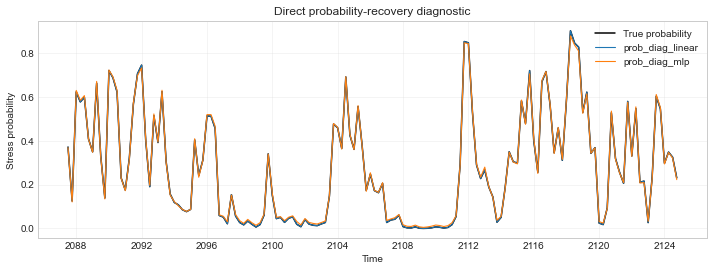

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
truth = prob_diag.drop_duplicates("time").sort_values("time")
ax.plot(truth["time"], truth["true_stress_probability"], color="black", linewidth=1.5, label="True probability")
for model_name, group in prob_diag.groupby("model"):
    ax.plot(group["time"], group["predicted_stress_probability"], linewidth=1.1, label=model_name)
ax.set_title("Direct probability-recovery diagnostic")
ax.set_ylabel("Stress probability")
ax.set_xlabel("Time")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()


## 10. Base PTO results plot

The base PTO plot separates the true conditional charge-off mean from the realised noisy charge-off draw. No smoothing or arbitrary axis compression is applied.


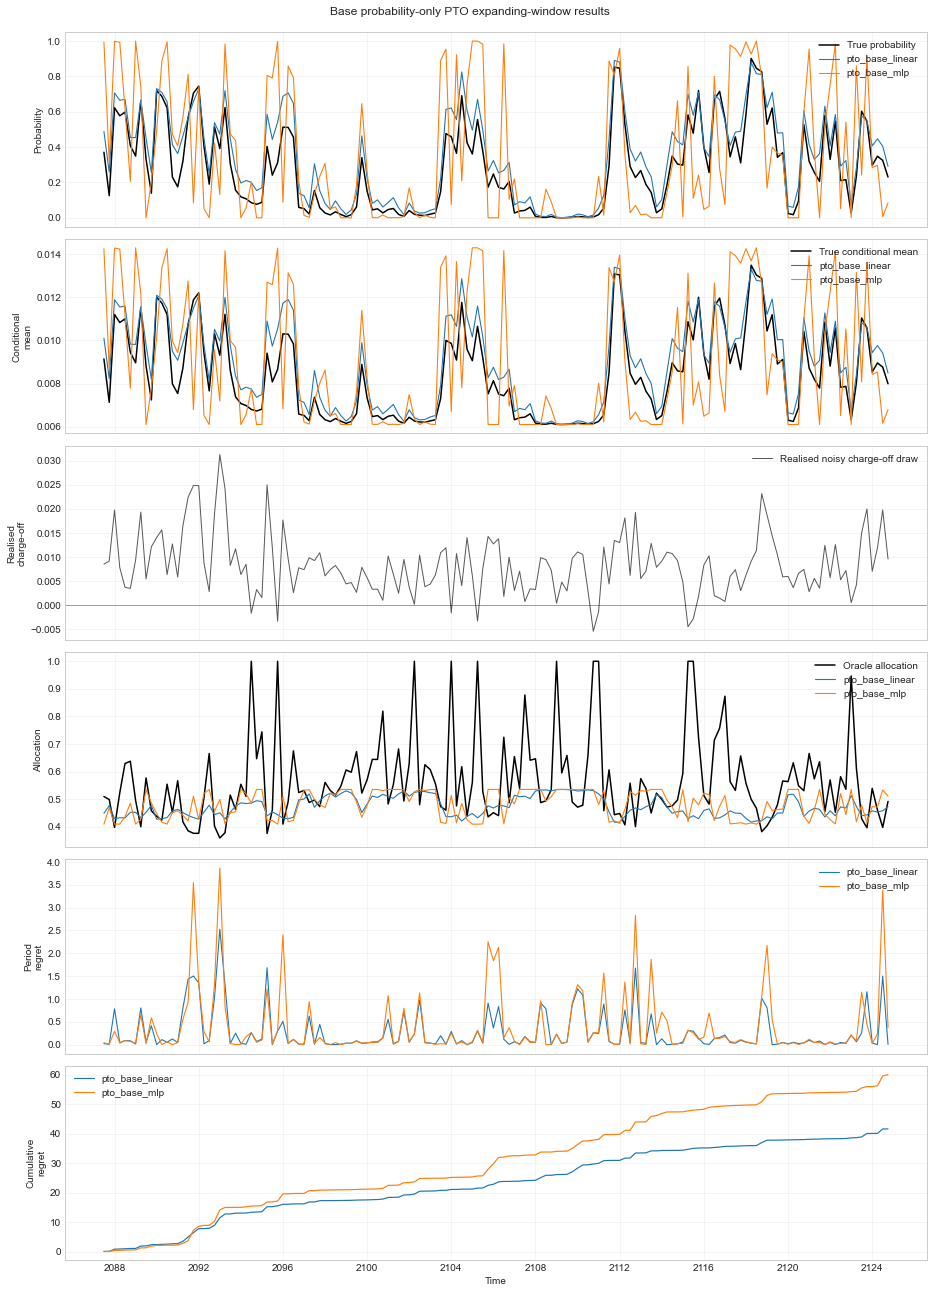

In [10]:
def plot_stage(stage_results, title, include_delta=False):
    models = list(stage_results["model"].unique())
    actual = stage_results.drop_duplicates("time").sort_values("time")
    n_panels = 7 if include_delta else 6
    fig, axes = plt.subplots(n_panels, 1, figsize=(13, 3.0 * n_panels), sharex=True)

    axes[0].plot(actual["time"], actual["true_stress_probability"], color="black", linewidth=1.5, label="True probability")
    for model_name, group in stage_results.groupby("model"):
        axes[0].plot(group["time"], group["predicted_stress_probability"], linewidth=1.1, label=model_name)
    axes[0].set_ylabel("Probability")
    axes[0].legend(loc="upper right")

    panel = 1
    if include_delta:
        for model_name, group in stage_results.groupby("model"):
            axes[panel].plot(group["time"], group["predicted_delta"], linewidth=1.1, label=model_name)
        axes[panel].axhline(train_cfg.delta_max, color="black", linestyle=":", linewidth=0.8)
        axes[panel].axhline(-train_cfg.delta_max, color="black", linestyle=":", linewidth=0.8)
        axes[panel].set_ylabel("Delta\n(decimal)")
        axes[panel].legend(loc="upper right")
        panel += 1

    axes[panel].plot(actual["time"], actual["true_conditional_mean_charge_off"], color="black", linewidth=1.5, label="True conditional mean")
    for model_name, group in stage_results.groupby("model"):
        axes[panel].plot(group["time"], group["predicted_mean_charge_off"], linewidth=1.1, label=model_name)
    axes[panel].set_ylabel("Conditional\nmean")
    axes[panel].legend(loc="upper right")
    panel += 1

    axes[panel].plot(actual["time"], actual["realised_charge_off_rate"], color="0.35", linewidth=1.0, label="Realised noisy charge-off draw")
    axes[panel].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
    axes[panel].set_ylabel("Realised\ncharge-off")
    axes[panel].legend(loc="upper right")
    panel += 1

    axes[panel].plot(actual["time"], actual["oracle_alpha"], color="black", linewidth=1.5, label="Oracle allocation")
    for model_name, group in stage_results.groupby("model"):
        axes[panel].plot(group["time"], group["predicted_alpha"], linewidth=1.1, label=model_name)
    axes[panel].set_ylabel("Allocation")
    axes[panel].legend(loc="upper right")
    panel += 1

    for model_name, group in stage_results.groupby("model"):
        axes[panel].plot(group["time"], group["regret"], linewidth=1.1, label=model_name)
    axes[panel].set_ylabel("Period\nregret")
    axes[panel].legend(loc="upper right")
    panel += 1

    for model_name, group in stage_results.groupby("model"):
        axes[panel].plot(group["time"], group["cumulative_regret"], linewidth=1.2, label=model_name)
    axes[panel].set_ylabel("Cumulative\nregret")
    axes[panel].set_xlabel("Time")
    axes[panel].legend(loc="upper left")

    for ax in axes:
        ax.grid(True, alpha=0.25)
    fig.suptitle(title, y=0.995)
    fig.tight_layout()
    plt.show()


plot_stage(base_results, "Base probability-only PTO expanding-window results", include_delta=False)


## 11. Delta PTO results plot

The delta models are plotted separately so their behaviour cannot obscure whether the basic probability-based PTO model is working.


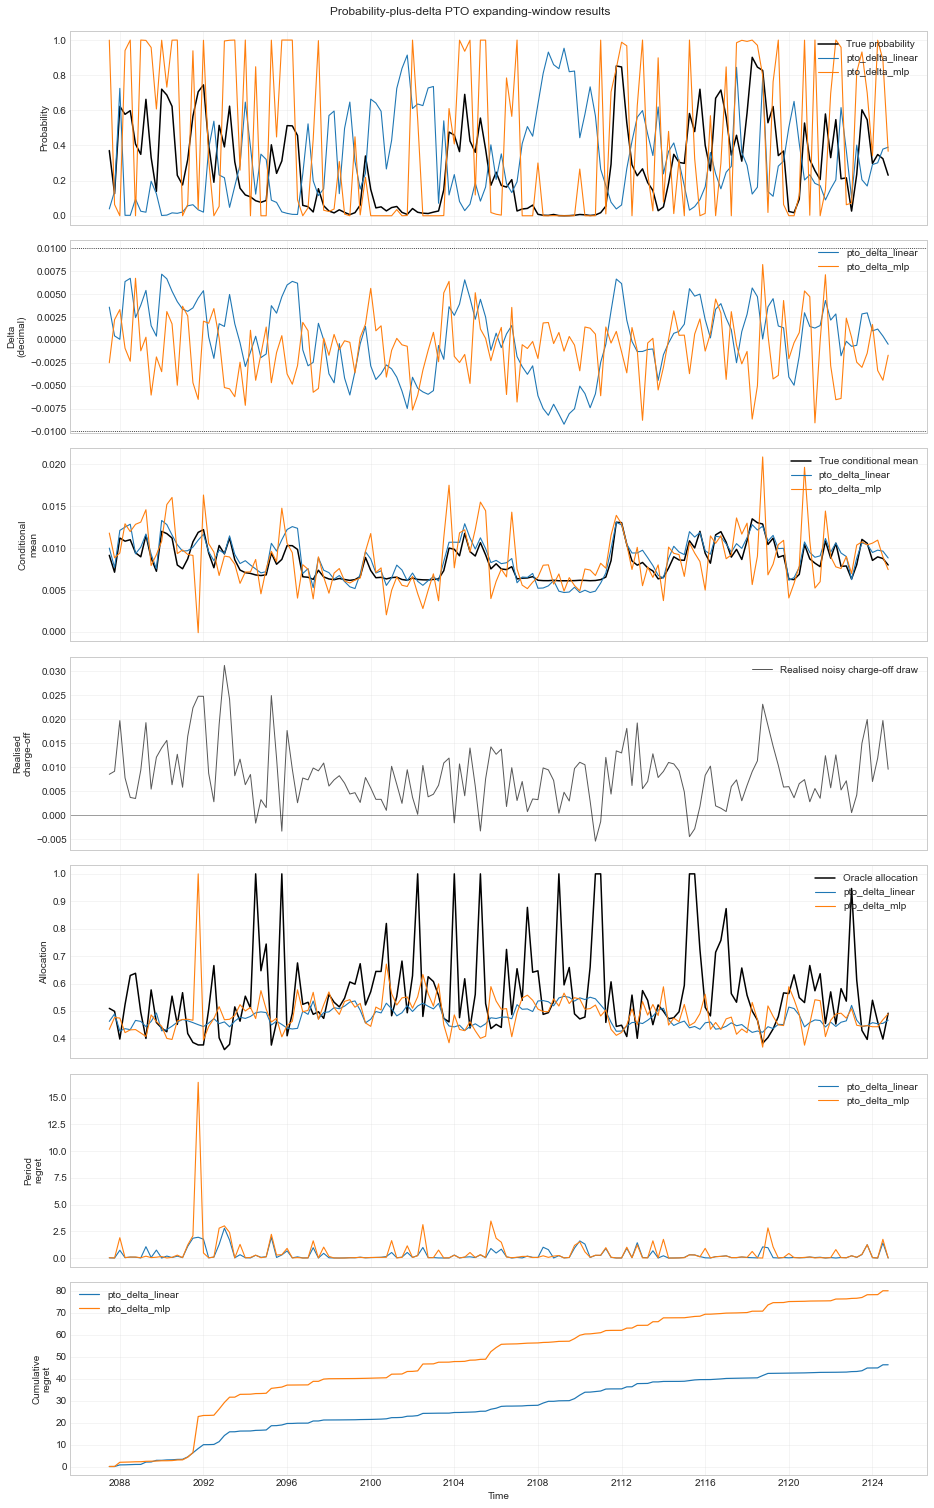

In [11]:
plot_stage(delta_results, "Probability-plus-delta PTO expanding-window results", include_delta=True)


## 12. Save results

The saved PTO results contain both stages and all anti-collapse diagnostic columns needed for downstream inspection.


In [12]:
results_dir = REPO_ROOT / "models" / "simulation" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

results_csv = results_dir / "pto_simulation_results.csv"
results.to_csv(results_csv, index=False)

prob_diag_csv = results_dir / "pto_probability_diagnostic_results.csv"
prob_diag.to_csv(prob_diag_csv, index=False)

print(f"Saved PTO simulation results to: {results_csv.relative_to(REPO_ROOT)}")
print(f"Saved probability diagnostic results to: {prob_diag_csv.relative_to(REPO_ROOT)}")
display(results.head())


Saved PTO simulation results to: models/simulation/results/pto_simulation_results.csv
Saved probability diagnostic results to: models/simulation/results/pto_probability_diagnostic_results.csv


,feature_time,time,stage,model,train_size,true_stress_probability,stress_regime,predicted_stress_probability,predicted_delta,base_mixture_mean,predicted_mean_charge_off,true_conditional_mean_charge_off,realised_charge_off_rate,predicted_normal_mean,predicted_stress_mean,predicted_alpha,oracle_alpha,predicted_realised_utility,oracle_utility,regret,cumulative_regret
0,2087-07-01,2087-07-01,stage_1_base,pto_base_linear,350,0.371106,0,0.488321,0.0,0.010104,0.010104,0.009143,0.008538,0.0061,0.0143,0.448730,0.509431,1.186054,1.211222,0.025168,0.025168
1,2087-07-01,2087-07-01,stage_1_base,pto_base_mlp,350,0.371106,0,0.994590,0.0,0.014256,0.014256,0.009143,0.008538,0.0061,0.0143,0.409469,0.509431,1.169775,1.211222,0.041447,0.041447
2,2087-10-01,2087-10-01,stage_1_base,pto_base_linear,351,0.125505,0,0.258437,0.0,0.008219,0.008219,0.007129,0.009174,0.0061,0.0143,0.476719,0.498504,1.194627,1.203521,0.008894,0.034062
3,2087-10-01,2087-10-01,stage_1_base,pto_base_mlp,351,0.125505,0,0.314242,0.0,0.008677,0.008677,0.007129,0.009174,0.0061,0.0143,0.468943,0.498504,1.191453,1.203521,0.012069,0.053515
4,2088-01-01,2088-01-01,stage_1_base,pto_base_linear,352,0.622732,1,0.706368,0.0,0.011892,0.011892,0.011206,0.019739,0.0061,0.0143,0.429087,0.397475,0.334540,1.120281,0.785742,0.819804
